In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
from Base_Modules.Environments import Prison
from Prison_Strategies.Basic_Strategies import *
from Prison_Strategies.Reinforcement_Learning_Strategies import *
from Base_Modules.Game_Master import Game_Master
from Base_Modules.Action import Action_History, Prison_Actions, Duel_Matrix
import pandas as pd
from collections import defaultdict

## Setup

In [81]:
prison = Prison()
actions = prison.Get_Actions()

In [82]:
q_models_folder = "Q_Learning_Models/"
q_learning = Q_Learning(actions=actions, state_size=1)
q_learning.Load_Q_Table(q_models_folder + "best_Q_Model_v2_first_place.pkl")
q_learning.Eval()

In [83]:
strategies_list = [
    q_learning,
    Random_Strategy(actions=actions, p_coop=0.1),
    Random_Strategy(actions=actions),
    Always_Betray(actions=actions),
    Always_Cooperate(actions=actions),
    Patient_Unforgiving(actions=actions, patience=1),
    Copycat(actions=actions),
    Periodic(actions=actions, period=4),
    Forgiving(actions=actions, p_forgive=0.1),
]

number_of_strategies = len(strategies_list)

In [84]:
strategies = {}

for (i, s) in enumerate(strategies_list):
    strategies[i] = s
    s.Set_ID(i)

In [85]:
def Get_Index_By_Name(strategies : dict[int, Strategy], name : str) -> int:
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s) == name:
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if  "".join(str(s).split(":")[1:]).startswith(name):
            return id
    for ix, (id, s) in enumerate(strategies.items()):
        if str(s).startswith(name):
            return id
    return -1

def get_name(id : int) -> str:
    return "".join(str(strategies[id]).split(":")[1:])


In [86]:
def Normal_Tournament(gm : Game_Master, number_of_games, total_games_explicit) -> tuple[Duel_Matrix, object]:
    return gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)

def RL_Training(gm : Game_Master, number_of_games, number_of_RL_epochs, total_games_explicit) -> Game_Master:
    for i in range(number_of_RL_epochs):
        gm.Tournament(number_of_games, Game_Master.Game_Type.All_Vs_All, total_games_explicit=total_games_explicit)
        gm.Reset()
        if (i)%1000 == 0:
            print(i)

In [87]:
number_of_games = 100
total_games_explicit = True
max_action_memory = -1

gm = Game_Master(prison, strategies=strategies, duel_size=2, max_action_memory=max_action_memory)

In [88]:
gm.Reset()
duel_matrix, rewards = Normal_Tournament(gm=gm, number_of_games=number_of_games, total_games_explicit=total_games_explicit)
rewards.Sort_Total_Rewards()

## Analysis


In [89]:
if 'q_learning' in locals() and isinstance(q_learning, Q_Learning):
    q_insight = {
        "Past Enemy Actions" : defaultdict(list),
        "Past Own Actions" : defaultdict(list),
        "Next Action" : defaultdict(pacts),
        "Reward" : defaultdict(float),
    }

    for ix, (s, a) in enumerate(q_learning.q_table.items()):
        state_size = len(s)
        for i in range((state_size - 1) // 2):
            q_insight["Past Enemy Actions"][ix].append(s[i*2])
            q_insight["Past Own Actions"][ix].append(s[i*2 + 1])
        q_insight["Next Action"][ix] = (s[-1])
        q_insight["Reward"][ix] = (a)

    display(pd.DataFrame(q_insight).round(3))

,Past Enemy Actions,Past Own Actions,Next Action,Reward
0,[Cooperate],[Betray],Cooperate,204.255
1,[Cooperate],[Betray],Betray,207.601
3,[Betray],[Betray],Cooperate,205.913
4,[Betray],[Betray],Betray,208.456
5,[Cooperate],[Cooperate],Cooperate,208.325
6,[Cooperate],[Cooperate],Betray,203.505
7,[Betray],[Cooperate],Cooperate,201.343
8,[Betray],[Cooperate],Betray,207.223
2,NaN,NaN,Cooperate,204.576
9,NaN,NaN,Betray,204.466


In [90]:
def Sort_Based_On_Total_Rewards(total_rewards, data):
    sorted_data = dict(sorted(
        data.items(),
        key=lambda kv: total_rewards.get(kv[0], 0),
        reverse=True
    ))
    return sorted_data

In [91]:
total_rewards = rewards.Get_Total_Rewards()
total_rewards_per_name = {str(strategies[i]):total_rewards[i] for i in total_rewards.keys()}

average_rewards_per_match = {k: (float(v)/number_of_strategies) for k, v in total_rewards.items()}
average_rewards_per_round = {k: (float(v)/(number_of_games*number_of_strategies)) for k, v in total_rewards.items()}

duel_rewards = rewards.Get_All_Duel_Rewards()

duel_rewards = dict(sorted(duel_rewards.items(), key=lambda kv: total_rewards.get(kv[0][0]), reverse=True))

In [92]:
largest_shared_victory = -float("inf")
least_shared_victory = float("inf")

for (_, rewards) in duel_rewards.items():
    largest_shared_victory = max(largest_shared_victory, sum(rewards.values()))
    least_shared_victory = min(least_shared_victory, sum(rewards.values()))


print(f"Largest shared reward: {largest_shared_victory}")
print(f"Least shared reward: {least_shared_victory}")


Largest shared reward: 600
Least shared reward: 203


In [93]:
from Base_Modules.Nemesis import Nemesis_Best_Enemy_Score, Nemesis_Worst_Score, Nemesis_Largest_Difference

criterion = Nemesis_Worst_Score

nemesis = criterion.Get_Nemesis(duel_rewards=duel_rewards)
nemesis = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=nemesis)
nemesis_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=nemesis)

nemesis_df = pd.DataFrame(
    [(k, v[0]) for k, v in nemesis_per_name.items()],
    columns=["Strategy", "Its nemesis"]
)

In [94]:
from Base_Modules.Nemesis import Friend_Best_Total_Score, Friend_Best_Own_Score

criterion = Friend_Best_Own_Score

friends = criterion.Get_Nemesis(duel_rewards=duel_rewards)
friends = Sort_Based_On_Total_Rewards(total_rewards=total_rewards, data=friends)
friends_per_name = criterion.Translate_Nemesis_To_Strategy_Names(strategies=strategies, nemesis=friends)

friends_df = pd.DataFrame(
    [(k, v[0]) for k, v in friends_per_name.items()],
    columns=["Strategy", "Its friend"]
)

In [95]:
cooperate_stats_per_strategy = {}
for s in strategies.keys():
    stats = duel_matrix.Get_Action_Statistics_Of_Strategy(s)
    cooperate_stats_per_strategy[s] = stats[Prison_Actions.Cooperate]/sum(stats.values())

action_stats_df = pd.DataFrame(
    [(get_name(s), v) for s,v in cooperate_stats_per_strategy.items()],
    columns=["Strategy", "% Coop"]
)
# display(action_stats_df.round(2))

## Results

In [96]:
summary = {}
for ix, (id, score) in enumerate(total_rewards.items()):
    summary[ix+1] = {"Name": get_name(id),
                   "Average score": average_rewards_per_round[id],
                   "Fraction of Co-ops": cooperate_stats_per_strategy[id],
                   "Nemesis": get_name(nemesis[id][0]),
                   "Friend": get_name(friends[id][0]),
                    }

summary_df = pd.DataFrame.from_dict(summary, orient="index")
summary_df.index.name = "Place"

display(summary_df.round(2))

,Name,Average score,Fraction of Co-ops,Nemesis,Friend
Place,,,,,
1,Q_Learning,2.27,0.51,Always_Betray,Random_Strategy (p_coop=0.5)
2,Patient_Unforgiving (patience=1),2.22,0.51,Always_Betray,Q_Learning
3,Forgiving (p_forgive=0.1),2.16,0.60,Always_Betray,Q_Learning
4,Copycat (1st=Cooperate),2.08,0.63,Always_Betray,Q_Learning
5,Always_Betray,1.90,0.00,Q_Learning,Always_Cooperate
6,Random_Strategy (p_coop=0.1),1.81,0.09,Always_Betray,Always_Cooperate
7,Always_Cooperate,1.68,1.00,Always_Betray,Q_Learning
8,Periodic (period=4),1.39,0.50,Always_Betray,Always_Cooperate
9,Random_Strategy (p_coop=0.5),1.38,0.48,Always_Betray,Always_Cooperate


## Dataframes

In [97]:
average_reward_per_round_df = pd.DataFrame.from_dict(average_rewards_per_round, orient="index", columns=["Average Reward"])
average_reward_per_round_df.index.name = "Strategy Name"
average_reward_per_round_df = average_reward_per_round_df.round(3)

In [98]:
average_reward_per_match_df = pd.DataFrame.from_dict(average_rewards_per_match, orient="index", columns=["Average Reward"])
average_reward_per_match_df.index.name = "Strategy Name"
average_reward_per_match_df = average_reward_per_match_df.round(3)

In [99]:
strat_names = [str(strategies[s]) for s in total_rewards.keys()]

score_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

coof = number_of_games

for (s1, s2), scores in duel_rewards.items():
    score_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2]/coof, scores[s1]/coof)
    score_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s1]/coof, scores[s2]/coof)

for s in strat_names:
    score_matrix.loc[s, s] = (0, 0)

In [100]:
sum_matrix = pd.DataFrame(index=strat_names, columns=strat_names, dtype=object)

for (s1, s2), scores in duel_rewards.items():
    sum_matrix.loc[str(strategies[s2]), str(strategies[s1])] = (scores[s2] + scores[s1])
    sum_matrix.loc[str(strategies[s1]), str(strategies[s2])] = (scores[s2] + scores[s1])

for s in strat_names:
    sum_matrix.loc[s, s] = 0

In [101]:
victory_matrix = score_matrix.apply(lambda col: col.map(lambda x: int(x[0] > x[1])))
for s in strat_names:
    victory_matrix.loc[s, s] = float("NaN")

In [102]:
def color_cell(x):
    if not isinstance(x, tuple):
        return ""
    if x[0] == 0 and x[1] == 0:
        return "background-color: black"
    elif x[0] > x[1]:
        return "background-color: green"
    elif x[0] < x[1]:
        return "background-color: darkred"
    else:
        return "background-color: gray"

styled_score_matrix = (
    score_matrix.style
    .map(color_cell)
    .set_properties(**{
        "border": "1px solid black"
    })
    .set_table_styles([
        {"selector": "th", "props": [("border", "2px solid black")]},
        {"selector": "td", "props": [("border", "2px solid black")]}
    ])
)

display(styled_score_matrix)

,(0):Q_Learning,(5):Patient_Unforgiving (patience=1),(8):Forgiving (p_forgive=0.1),(6):Copycat (1st=Cooperate),(3):Always_Betray,(1):Random_Strategy (p_coop=0.1),(4):Always_Cooperate,(7):Periodic (period=4),(2):Random_Strategy (p_coop=0.5)
(0):Q_Learning,"(0, 0)","(3.0, 3.0)","(3.0, 3.0)","(3.0, 3.0)","(0.99, 1.04)","(1.43, 0.93)","(3.0, 3.0)","(2.91, 0.66)","(3.09, 0.54)"
(5):Patient_Unforgiving (patience=1),"(3.0, 3.0)","(0, 0)","(3.0, 3.0)","(3.0, 3.0)","(0.99, 1.04)","(1.15, 1.0)","(3.0, 3.0)","(2.91, 0.66)","(2.93, 0.58)"
(8):Forgiving (p_forgive=0.1),"(3.0, 3.0)","(3.0, 3.0)","(0, 0)","(3.0, 3.0)","(0.81, 1.76)","(1.32, 1.57)","(3.0, 3.0)","(2.7, 1.2)","(2.61, 1.46)"
(6):Copycat (1st=Cooperate),"(3.0, 3.0)","(3.0, 3.0)","(3.0, 3.0)","(0, 0)","(0.99, 1.04)","(1.16, 1.21)","(3.0, 3.0)","(2.45, 2.5)","(2.14, 2.19)"
(3):Always_Betray,"(1.04, 0.99)","(1.04, 0.99)","(1.76, 0.81)","(1.04, 0.99)","(0, 0)","(1.36, 0.91)","(5.0, 0.0)","(3.0, 0.5)","(2.88, 0.53)"
(1):Random_Strategy (p_coop=0.1),"(0.93, 1.43)","(1.0, 1.15)","(1.57, 1.32)","(1.21, 1.16)","(0.91, 1.36)","(0, 0)","(4.8, 0.3)","(2.82, 0.87)","(3.01, 0.76)"
(4):Always_Cooperate,"(3.0, 3.0)","(3.0, 3.0)","(3.0, 3.0)","(3.0, 3.0)","(0.0, 5.0)","(0.3, 4.8)","(0, 0)","(1.5, 4.0)","(1.35, 4.1)"
(7):Periodic (period=4),"(0.66, 2.91)","(0.66, 2.91)","(1.2, 2.7)","(2.5, 2.45)","(0.5, 3.0)","(0.87, 2.82)","(4.0, 1.5)","(0, 0)","(2.1, 2.3)"
(2):Random_Strategy (p_coop=0.5),"(0.54, 3.09)","(0.58, 2.93)","(1.46, 2.61)","(2.19, 2.14)","(0.53, 2.88)","(0.76, 3.01)","(4.1, 1.35)","(2.3, 2.1)","(0, 0)"


In [103]:
import webbrowser
store_styled_matrix_in_html = False
if store_styled_matrix_in_html:
    styled_score_matrix.to_html("styled_score_matrix.html")
    webbrowser.open_new_tab("styled_score_matrix.html")

## Plots



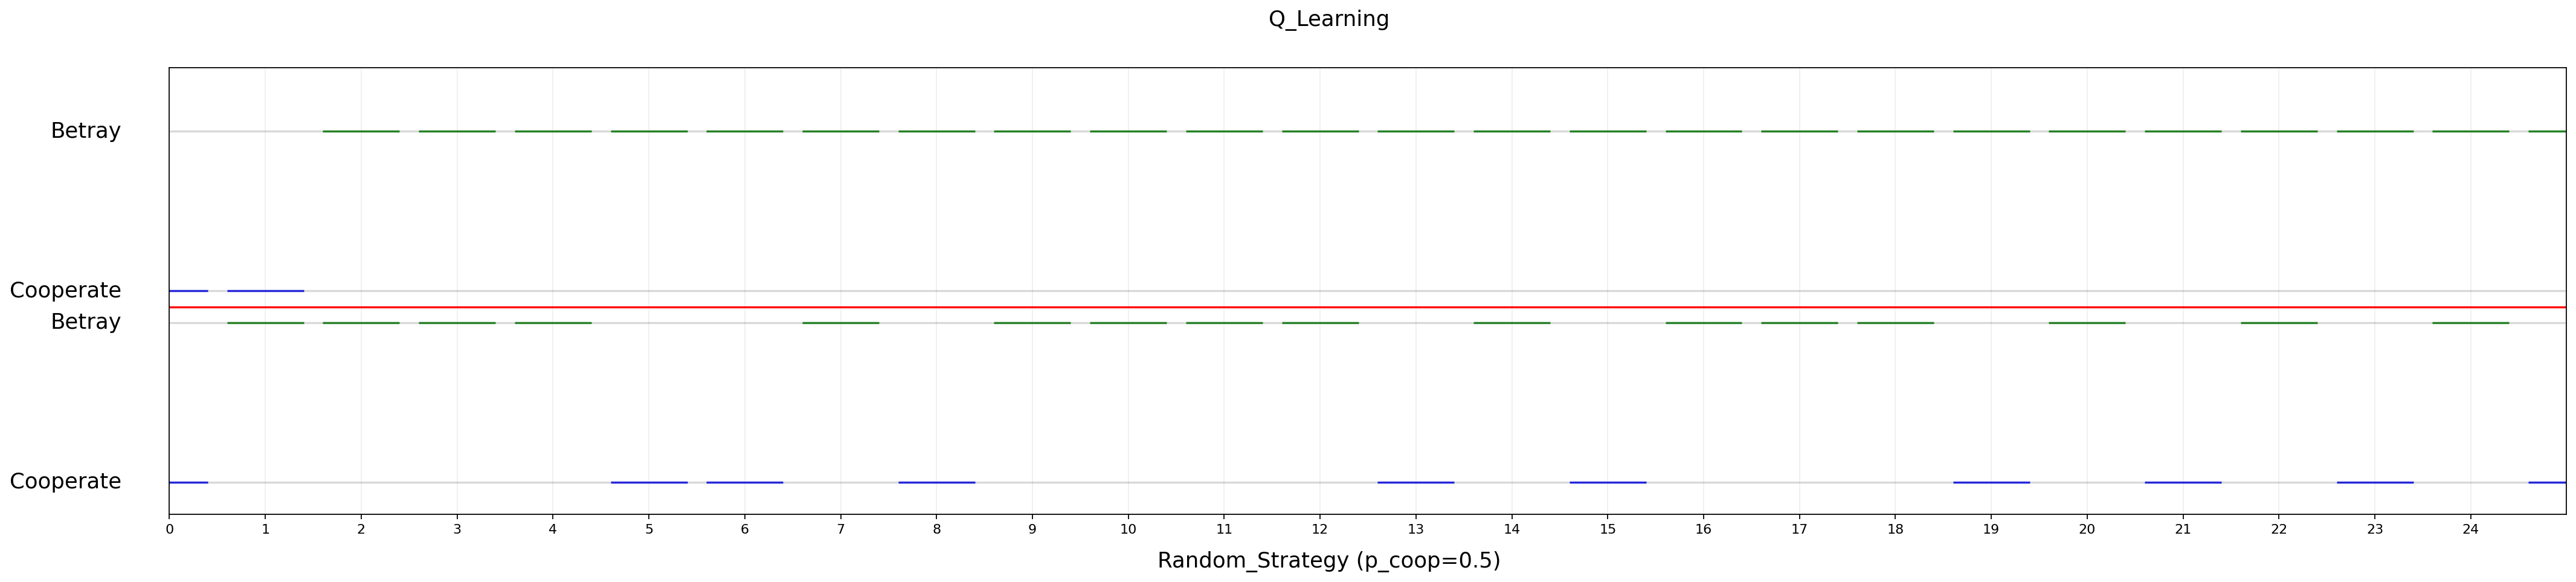

In [104]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x_min = 0
x_max = 25
strategy1_name = "Q"
strategy2_name = "Random_Strategy (p_coop=0.5)"

strategy1_ID = Get_Index_By_Name(strategies=strategies, name=strategy1_name)
strategy2_ID = Get_Index_By_Name(strategies=strategies, name=strategy2_name)

assert(strategy1_ID>=0 and strategy2_ID>=0), "Strategy not found."

fontsize=16

smin = min(strategy1_ID, strategy2_ID)
smax = max(strategy1_ID, strategy2_ID)

strategy1_ID = smin
strategy2_ID = smax

data = duel_matrix.Get_Action_History((strategy1_ID, strategy2_ID)).Get_Action_History()

fig = plt.figure(figsize=(32, 6), dpi=160)
y_scale = 0.5
y_offset = 0.6

for i, (key, values) in enumerate(data.items()):
    y, c = [v.value*y_scale - y_offset*i for v in values], ["b" if v.value==0 else "g" for v in values]
    x = list(range(len(y)))

    # plt.step(x, y, where='post', label=f"Signal {key}")
    # plt.scatter(x, y, label=f"Signal {key}")
    for i, val in enumerate(y):
        plt.hlines(val, float(float(i)-0.4), float(float(i)+0.4), colors=[c[i]])

plt.hlines(y = -0.05, xmin=x_min, xmax=x_max, colors=["r"], linestyles="-")
plt.hlines(y = 0, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = y_scale-y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)
plt.hlines(y = -y_offset, xmin=x_min, xmax=x_max, colors="gray", linestyles="-", alpha=0.3)

plt.xlim([x_min, x_max])
plt.ylim([-y_offset-0.1, y_offset+0.1])
plt.yticks([])
plt.ylabel("")
plt.suptitle(f"{get_name(strategy1_ID)}", fontsize=fontsize, ha="center")


ax = plt.gca()

ax.text(-0.02, 0, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, y_scale, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)

ax.text(-0.02, y_scale-y_offset, 'Betray', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)
ax.text(-0.02, -y_offset, 'Cooperate', transform=ax.get_yaxis_transform(),
        va='center', ha='right', fontsize=fontsize)


fig.text(0.5, 0.01, f"{get_name(strategy2_ID)}", ha='center', va='bottom', fontsize=fontsize)

ax.set_xticks(np.arange(x_min, x_max, 1))
ax.grid(True, alpha=0.2)

plt.show()